# Classification Exercise – vehicles.csv

In this exercise, you will solve a classification problem using the `vehicles.csv` dataset.
Your goal is to build a Logistic Regression model and compare its performance with Support Vector Machine (SVM) models (with and without normalization).

## 1. Import libraries
Complete the necessary imports.

In [24]:
# TODO: import the required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data loading and preprocessing
- Load the `vehicles.csv` file
- Separate features (X) and target variable (y)
- Split the data into training and test sets

In [25]:
#loading data
df = pd.read_csv('vehicles.csv', encoding='utf-8-sig')
#listing columns to pick a target
print(df.columns.tolist())

['barrels08', 'barrelsA08', 'charge120', 'charge240', 'city08', 'city08U', 'cityA08', 'cityA08U', 'cityCD', 'cityE', 'cityUF', 'co2', 'co2A', 'co2TailpipeAGpm', 'co2TailpipeGpm', 'comb08', 'comb08U', 'combA08', 'combA08U', 'combE', 'combinedCD', 'combinedUF', 'cylinders', 'displ', 'drive', 'engId', 'eng_dscr', 'feScore', 'fuelCost08', 'fuelCostA08', 'fuelType', 'fuelType1', 'ghgScore', 'ghgScoreA', 'highway08', 'highway08U', 'highwayA08', 'highwayA08U', 'highwayCD', 'highwayE', 'highwayUF', 'hlv', 'hpv', 'id', 'lv2', 'lv4', 'make', 'model', 'mpgData', 'phevBlended', 'pv2', 'pv4', 'range', 'rangeCity', 'rangeCityA', 'rangeHwy', 'rangeHwyA', 'trany', 'UCity', 'UCityA', 'UHighway', 'UHighwayA', 'VClass', 'year', 'youSaveSpend', 'guzzler', 'trans_dscr', 'tCharger', 'sCharger', 'atvType', 'fuelType2', 'rangeA', 'evMotor', 'mfrCode', 'c240Dscr', 'charge240b', 'c240bDscr', 'createdOn', 'modifiedOn', 'startStop', 'phevCity', 'phevHwy', 'phevComb']


C:\Users\tagay\AppData\Local\Temp\ipykernel_8572\1098085294.py:2: DtypeWarning: Columns (0: fuelType2, 1: rangeA, 2: evMotor, 3: mfrCode, 4: c240Dscr, 5: c240bDscr, 6: startStop) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('vehicles.csv', encoding='utf-8-sig')


In [26]:
#checking picked coulmn if it is clean
df['VClass'].value_counts()

VClass
Compact Cars                          5972
Subcompact Cars                       5244
Midsize Cars                          5019
Standard Pickup Trucks                2354
Large Cars                            2277
Two Seaters                           2115
Sport Utility Vehicle - 4WD           2090
Small Station Wagons                  1636
Sport Utility Vehicle - 2WD           1627
Special Purpose Vehicles              1455
Minicompact Cars                      1413
Standard Pickup Trucks 2WD            1297
Vans                                  1141
Standard Pickup Trucks 4WD            1134
Small Sport Utility Vehicle 4WD        975
Standard Sport Utility Vehicle 4WD     771
Special Purpose Vehicle 2WD            677
Small Sport Utility Vehicle 2WD        666
Midsize-Large Station Wagons           656
Midsize Station Wagons                 553
Small Pickup Trucks                    538
Small Pickup Trucks 2WD                477
Vans, Cargo Type                       438
Mini

In [ ]:
# TODO: load and prepare the data

# 1. Filter out rare classes
class_counts = df['VClass'].value_counts()
valid_classes = class_counts[class_counts > 1].index
df = df[df['VClass'].isin(valid_classes)]

# Pick a few important categorical features to encode
columns_to_encode = ['drive', 'fuelType', 'trany'] 

# One-hot encode those specific columns
df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)

# Now filter down to ONLY numeric/boolean columns (dropping the remaining un-encoded text)
numeric_and_encoded_cols = df_encoded.select_dtypes(include=['number', 'bool']).columns
df_final = df_encoded[numeric_and_encoded_cols].fillna(0) # Also fills missing numbers with 0

# 2. Separate features (X) and target variable (y)
X = df_final.drop('VClass', axis=1, errors='ignore') # features
y = df['VClass']                                     # target (from original df)

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {X_test.shape}")

Shape of X_train: (33720, 116)
Shape of X_test: (8431, 116)
Shape of y_train: (33720,)
Shape of y_train: (8431, 116)


## 3. Logistic Regression
- Train a Logistic Regression model
- Evaluate its performance

In [29]:
# TODO: train and evaluate Logistic Regression
# 1. Initialize and train the Logistic Regression model
# (We use max_iter=1000 to give the model enough time to calculate the weights for all 116 columns)
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

# 2. Make predictions on the test set
y_pred_log = log_model.predict(X_test)

# 3. Evaluate the performance
log_accuracy = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {log_accuracy:.4f}")

Logistic Regression Accuracy: 0.3825


c:\dev\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 4. SVM (without normalization)
- Train an SVM model on the original data
- Evaluate its performance

In [30]:
# TODO: SVM without scaling
# 1. Initialize the Support Vector Classifier
svm_unscaled = SVC(random_state=42)

# 2. Train the model
print("Training SVM on unscaled data... please wait...")
svm_unscaled.fit(X_train, y_train)

# 3. Make predictions
print("Predicting...")
y_pred_svm_unscaled = svm_unscaled.predict(X_test)

# 4. Evaluate the performance
svm_unscaled_accuracy = accuracy_score(y_test, y_pred_svm_unscaled)
print(f"SVM (Unscaled) Accuracy: {svm_unscaled_accuracy:.4f}")

Training SVM on unscaled data... please wait...
Predicting...
SVM (Unscaled) Accuracy: 0.2289


## 5. SVM (with normalization)
- Normalize the data (e.g., using StandardScaler)
- Train an SVM model
- Evaluate its performance

In [31]:
# TODO: scaling + SVM
# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Fit the scaler on the training data, and immediately transform it
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the test data using the exact same scale
# IMPORTANT: We only use .transform() here, NOT .fit_transform()! 
# We don't want the model to "peek" at the test data's averages.
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and train the new SVM model
svm_scaled = SVC(random_state=42)
print("Training SVM on SCALED data... please wait...")
svm_scaled.fit(X_train_scaled, y_train)

# 5. Make predictions and evaluate
print("Predicting...")
y_pred_svm_scaled = svm_scaled.predict(X_test_scaled)
svm_scaled_accuracy = accuracy_score(y_test, y_pred_svm_scaled)

print(f"SVM (Scaled) Accuracy: {svm_scaled_accuracy:.4f}")

Training SVM on SCALED data... please wait...
Predicting...
SVM (Scaled) Accuracy: 0.6680


## 6. Comparison
Compare the performance of the models (e.g., using accuracy).

- Which model performs the best?
- What is the effect of normalization on SVM performance?

In [32]:
# TODO: compare the results
print("--- Final Model Comparison ---")
print(f"Logistic Regression:   {log_accuracy:.4f}")
print(f"SVM (Unscaled):        {svm_unscaled_accuracy:.4f}")
print(f"SVM (Scaled):          {svm_scaled_accuracy:.4f}")

--- Final Model Comparison ---
Logistic Regression:   0.3825
SVM (Unscaled):        0.2289
SVM (Scaled):          0.6680


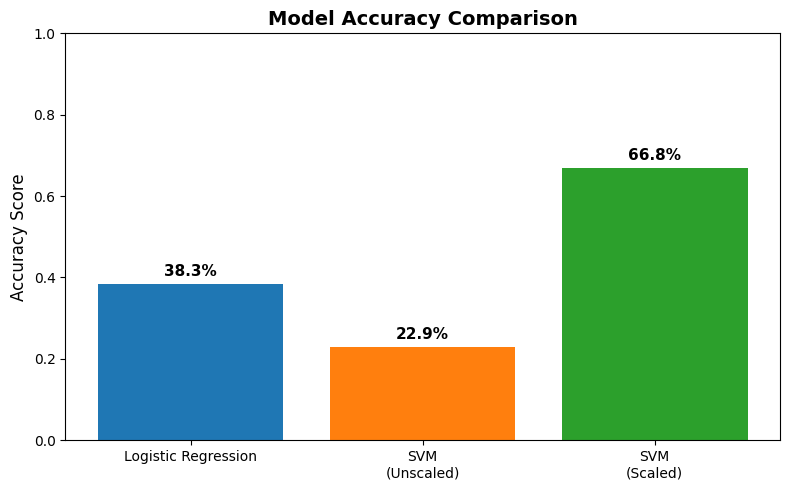

In [33]:
# 1. Store our model names and their corresponding accuracy scores
models = ['Logistic Regression', 'SVM\n(Unscaled)', 'SVM\n(Scaled)']
accuracies = [log_accuracy, svm_unscaled_accuracy, svm_scaled_accuracy]

# 2. Set up the matplotlib figure
plt.figure(figsize=(8, 5))

# 3. Create a bar chart with 3 different colors
bars = plt.bar(models, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

# 4. Add titles and labels to make it look professional
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 1.0) # Lock the Y-axis between 0 (0%) and 1 (100%)

# 5. Add the exact percentage text on top of each bar!
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, 
             f'{height:.1%}', ha='center', fontsize=11, fontweight='bold')

# 6. Display the plot
plt.tight_layout()
plt.show()